In [1]:
import re
import pandas as pd
from urllib.request import urlopen
from io import StringIO
import numpy as np
import astropy.units as u
from astropy.time import Time
from numpy import sin, cos
from astropy.coordinates import EarthLocation, get_body_barycentric_posvel, solar_system_ephemeris 
import adam_core.coordinates
import pyarrow as pa
from adam_core.time import Timestamp
from adam_core.coordinates import CartesianCoordinates, Origin
from adam_core.constants import KM_P_AU, S_P_DAY
from adam_core.orbits import Orbits
from adam_core.utils import get_perturber_state
from adam_core.coordinates.origin import OriginCodes
from scipy.interpolate import RegularGridInterpolator
import matplotlib.pyplot as plt


In [2]:
import re
import pandas as pd
from urllib.request import urlopen
from io import StringIO
import numpy as np

url = "https://www2.boulder.swri.edu/~davidn/NEOMOD_Simulator/input_neomod3.dat"


text = urlopen(url).read().decode("utf-8", errors="ignore")
lines = text.splitlines()

# to find the header row
header_idx = next(
    i for i, ln in enumerate(lines)
    if re.match(r"^\s*iH\s+ia\s+ie\s+ii\s+binned\s+mod\.\s+nu6\b", ln)
)

# merging binned and mod. into one, otherwise it becomes weird :\
raw_tokens = re.split(r"\s+", lines[header_idx].strip())
names = []
i = 0
while i < len(raw_tokens):
    if raw_tokens[i] == "binned" and i + 1 < len(raw_tokens) and raw_tokens[i+1].startswith("mod."):
        names.append("binned mod.")
        i += 2
    else:
        names.append(raw_tokens[i])
        i += 1

#skips blank or dashed lines
data_lines = []
for ln in lines[header_idx + 1:]:
    s = ln.strip()
    if not s or set(s) <= set("- "):    # separators/blank
        continue
    if re.match(r"^\d", s):             
        data_lines.append(s)


df = pd.read_csv(StringIO("\n".join(data_lines)), sep=r"\s+", header=None, names=names)


df.head()

,iH,ia,ie,ii,binned mod.,nu6,3:1,5:2,7:3,8:3,9:4,11:5,2:1,inner,Hun,Pho,JFC
0,1,4,1,1,1.454600e-08,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,4,1,2,2.115800e-08,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,4,1,3,1.917400e-08,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,4,1,4,3.305900e-09,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,4,1,10,1.983600e-08,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
#to calc center of bins
n_H, H_min, H_max = 52, 15.0, 28.0
n_a, a_min, a_max = 42, 0.0, 4.2
n_e, e_min, e_max = 25, 0.0, 1.0
n_i, i_min, i_max = 22, 0.0, 88.0

da = (a_max - a_min)/(n_a) #bin width
de = (e_max - e_min)/(n_e)
di = (i_max - i_min)/(n_i)
dH = (H_max - H_min)/n_H

#bin center coords
a_center = a_min + (np.arange(n_a) + 0.5) * da
e_center = e_min + (np.arange(n_e) + 0.5) * de
i_center = i_min + (np.arange(n_i) + 0.5) * di
H_center = H_min + (np.arange(n_H) + 0.5) * dH

array4D = np.zeros((n_H, n_a, n_e, n_i))

idx = df[['iH', 'ia', 'ie', 'ii']].astype(int).values - 1  # 0-based indices
vals = df['binned mod.'].astype(float).values
array4D[idx[:,0], idx[:,1], idx[:,2], idx[:,3]] = vals

df["a_AU"] = a_min + (df["ia"] - 0.5) * da 
df["e"] = e_min + (df["ie"] - 0.5) * de

In [4]:
AU_km = 149_597_870.7
def sky_basis(ra_rad, dec_rad):
        l_hat = np.array([cos(dec_rad)*cos(ra_rad), # vector that points to object's pos on sky from observer
                          cos(dec_rad)*sin(ra_rad),
                          sin(dec_rad)])
        e_ra  = np.array([-sin(ra_rad),  cos(ra_rad), 0.0]) # vector towards increasing RA - points east, 90 deg to l_hat
        e_dec = np.array([-sin(dec_rad)*cos(ra_rad), # vector towards increasing dec - points north
                          -sin(dec_rad)*sin(ra_rad),
                          cos(dec_rad)])
        return l_hat, e_ra, e_dec # turning angular rates into linear velocities

def observables_to_geocentric_state(ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day,
                                    d_au, ddot_kms, ra_rate_is_plain_dalpha=False):
        # converting from degrees to radians
        ra  = np.deg2rad(ra_deg) 
        dec = np.deg2rad(dec_deg)
        l_hat, e_ra, e_dec = sky_basis(ra, dec)
         # angular rate conversion from deg/day to rad/s
        dra  = np.deg2rad(dra_deg_per_day)  / 86400.0
        ddec = np.deg2rad(ddec_deg_per_day) / 86400.0
        # if the RA rate is plain d alpha/dt, convert to u alpha⋅cos delta sky-plane rate
        if ra_rate_is_plain_dalpha:
             dra *= np.cos(dec)

        d_km = d_au * AU_km
        # multiplying l_hat by the rand dist. value gives actual geocentric pos vector of obj
        r_geo = d_km * l_hat  # vector from earth center to obj

        # speed
        v_rad = ddot_kms * l_hat
        v_tan = d_km * (dra * e_ra + ddec * e_dec)
        v_geo = v_rad + v_tan
        
        return r_geo, v_geo

def geo_to_topo(r_geo_km, v_geo_kms, rE, vE, r_obs, obstime):
        # convert r_geo, v_geo for obj to heliocentric r_topo, v_topo for an observer at rubin
        # from center of earth to an observer now at rubin
        obstime = Time(obstime)
        # earth's barycentric (heliocentric) state was done in previous step
        # so was observer's offset from center of earth
        # adding the offsets
        r_topo = rE + r_obs + r_geo_km
        v_topo = vE + v_geo_kms
        return r_topo, v_topo # asteroid position, vec going from sun to asteroid assuming youre at rubin
    

def safe_arccos(x):
        return np.arccos(np.clip(x, -1.0, 1.0))

def neomod3_slice_ae(H0, i0, a_grid, e_grid, interp4D): #fixes H, i, and creates a mesh of a, e
        pts = np.column_stack([np.full(a_grid.size, H0),
                               a_grid.ravel(),
                               e_grid.ravel(),
                               np.full(a_grid.size, i0)])
        log_w = interp4D(pts)
        w = np.exp(log_w).reshape(a_grid.shape)
        return w

def neomod3_at_orbit(a_val, e_val, H0, i0, interp4D):
        log_w = interp4D([[H0, a_val, e_val, i0]])[0]
        return float(np.exp(log_w))

def print_elements_debug(a_AU, e_val, i0, H0):
    print(f"[DEBUG] H={H0:.3f}, a={a_AU:.6f} AU, e={e_val:.6f}, i={i0:.6f} deg")

def score_from_elements(a_AU, e, H0, i0, interp4D):
    # checks if orbit is bound right
    if (a_AU <= 0) or (e >= 1.0) or (e < 0):
        # print("[INFO] Unbound/invalid elements  weight = 0")
        return 0.0

    # clip gently to model box
    a_cl = np.clip(a_AU, 0.0, 4.2 - 1e-9)
    e_cl = np.clip(e,      0.0, 1.0 - 1e-9)
    i_cl = np.clip(i0,  0.0, 88.0 - 1e-9)

    log_w = float(interp4D([[H0, a_cl, e_cl, i_cl]])[0])
    return 0.0 if not np.isfinite(log_w) else float(np.exp(log_w))


    
def compute_neomod3_weight(d_au, ddot_kms, 
                           ra_deg=10.0, dec_deg=20.0, 
                           dra_deg_per_day=0.12, ddec_deg_per_day=0.22,
                           H0=19.0, i0=25.9, obstime_str="2025-09-16T00:00:00", what="w"):
    obstime = Time(obstime_str)
    ra_rate_is_plain_dalpha = False
    #print("entered function compute_neomod3_weight")
    

    
    

    rubin_location = EarthLocation.from_geodetic( 
        lon=-70.7366*u.deg,   # longitude (west is negative)
        lat=-30.2407*u.deg,   # latitude
        height=2647*u.m       # elevation
        
    )
    # earth's barycentric vector rel to sun
    with solar_system_ephemeris.set('de432s'): 
        rE_bary, vE_bary = get_body_barycentric_posvel('earth', obstime)

    # convert to km and km/s arrays
    rE = np.array([rE_bary.x.to(u.km).value,
                   rE_bary.y.to(u.km).value,
                   rE_bary.z.to(u.km).value])
    
    vE = np.array([vE_bary.x.to(u.km/u.s).value,
                   vE_bary.y.to(u.km/u.s).value,
                   vE_bary.z.to(u.km/u.s).value])
    
    obs_geo = rubin_location.get_gcrs(obstime)
    r_obs = np.array([obs_geo.cartesian.x.to(u.km).value,
                      obs_geo.cartesian.y.to(u.km).value,
                      obs_geo.cartesian.z.to(u.km).value])
 

    r_geo, v_geo = observables_to_geocentric_state(ra_deg, dec_deg, dra_deg_per_day, ddec_deg_per_day, d_au, ddot_kms)

    r_helio, v_helio = geo_to_topo(r_geo, v_geo, rE, vE, r_obs, obstime) #so not running the random numbers anymore

    #print("Heliocentric position [km]:", r_helio)
    #print("Heliocentric velocity [km/s]:", v_helio)


        
    mu_sun = 1.32712440018e11  # [km^3/s^2] gm of the sun
    r_vec = np.array(r_helio, dtype=float)
    v_vec = np.array(v_helio, dtype=float)
    #print(r_vec)
    #print(v_vec)

    
    r = np.array(r_vec, dtype=float)
    v = np.array(v_vec, dtype=float)
    R = np.linalg.norm(r)
    V = np.linalg.norm(v)

    #r_helio = np.array([ 1.49731310e+08, -1.54951809e+07, -4.56222082e+06 ])  # km
    #r_vec here does the same thing but doesnt use random values so 
    #v_helio = np.array([ 4.15172845, 25.02778897, 12.21628245 ]) # km/s
    #same with v_vec 
    
    obstime = Time(["2025-09-16T00:00:00"], scale="tdb")  # Note converted this to a list 
    if r_vec.ndim == 1:
        r_vec = r_vec[np.newaxis, :]
        v_vec = v_vec[np.newaxis, :]

    
    cartesian_coordinates = CartesianCoordinates.from_kwargs(
        x=r_vec[:, 0] / KM_P_AU,
        y=r_vec[:, 1] / KM_P_AU,
        z=r_vec[:, 2] / KM_P_AU,
        vx=v_vec[:, 0] / KM_P_AU * S_P_DAY,
        vy=v_vec[:, 1] / KM_P_AU * S_P_DAY,
        vz=v_vec[:, 2] / KM_P_AU * S_P_DAY,
        time=Timestamp.from_astropy(obstime),
        origin=Origin.from_kwargs(code=pa.repeat("SUN", len(r_vec))),
        frame="equatorial" # ecliptic is the other choice
    )
    
    keplerian_coordinates = cartesian_coordinates.to_keplerian()
    
    
    # Might be useful to store them into an orbits object:
    orbits = Orbits.from_kwargs(
        orbit_id=[f"orbit_{i:08d}" for i in range(len(cartesian_coordinates))],
        coordinates=cartesian_coordinates,
    )
    # The Orbits class expects cartesian coordinates but its trivial to convert
    # so that log(0) doesn't happen
    _eps = 1e-300
    log_grid = np.log(array4D + _eps)
    interp4D = RegularGridInterpolator(
        (H_center, a_center, e_center, i_center),
        log_grid,
        bounds_error=False,
        fill_value=-np.inf
    )
    

    # fixed vals
    #H0 = 19.0         # abs magnitude
    #i0 = 10.0         # deg

    Na, Ne = 200, 200
    a_grid = np.linspace(a_min, a_max, Na)
    e_grid = np.linspace(e_min, e_max, Ne)
    A, E = np.meshgrid(a_grid, e_grid, indexing="xy")

    W = neomod3_slice_ae(H0, i0, A, E, interp4D)    

    

    #a_val, e_val = 0.915, 0.109
    a_val = keplerian_coordinates.a[0].as_py()
    e_val = keplerian_coordinates.e[0].as_py()
    #print(keplerian_coordinates.a)

    #print("PRE about to call neomod3_at_orbit")

    #print_elements_debug(a_val, e_val, i0, H0)
    
    score = score_from_elements(a_val, e_val, 19.0, 25.9, interp4D)

    
    #print(f"a = {a_val}, e = {e_val}")
    if what=="w":
        return score
    elif what=="a":
        return a_val
    elif what=="e":
        return e_val
    

        
        
    
    
    
    
                         
        
                   
                          

In [5]:
test_neomod = compute_neomod3_weight(
    d_au = 1.5,
    ddot_kms = 10.0,
    
)

print("NEOMOD3 weight score:", test_neomod)

NEOMOD3 weight score: 0.0


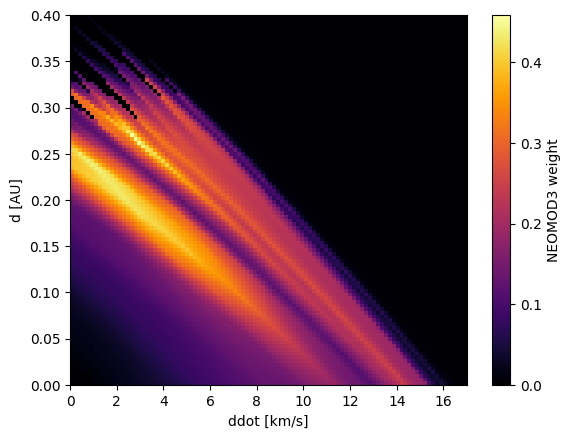

In [6]:
d_vals = np.linspace(0, 0.4, 100)   
v_vals = np.linspace(0, 17, 100)    
scores = np.zeros((len(d_vals), len(v_vals)))

for i, d in enumerate(d_vals):
    for j, v in enumerate(v_vals):
        scores[i, j] = compute_neomod3_weight(d_au=d, ddot_kms=v)



plt.imshow(scores, extent=[v_vals.min(), v_vals.max(), d_vals.min(), d_vals.max()],
           origin="lower", aspect="auto", cmap="inferno")
plt.colorbar(label="NEOMOD3 weight")
plt.xlabel("ddot [km/s]")
plt.ylabel("d [AU]")
plt.show()


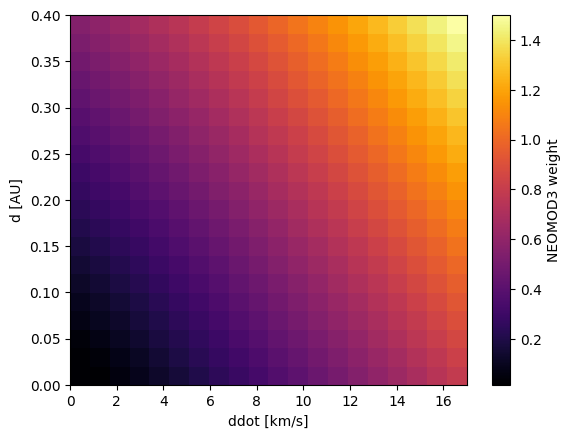

In [11]:
d_vals = np.linspace(0, 0.4, 20)   
v_vals = np.linspace(0, 17, 20)    
scores = np.zeros((len(d_vals), len(v_vals)))

for i, d in enumerate(d_vals):
    for j, v in enumerate(v_vals):
        scores[i, j] = compute_neomod3_weight(d_au=d, ddot_kms=v, what="e")



plt.imshow(scores, extent=[v_vals.min(), v_vals.max(), d_vals.min(), d_vals.max()],
           origin="lower", aspect="auto", cmap="inferno")
plt.colorbar(label="NEOMOD3 weight")
plt.xlabel("ddot [km/s]")
plt.ylabel("d [AU]")
plt.show()


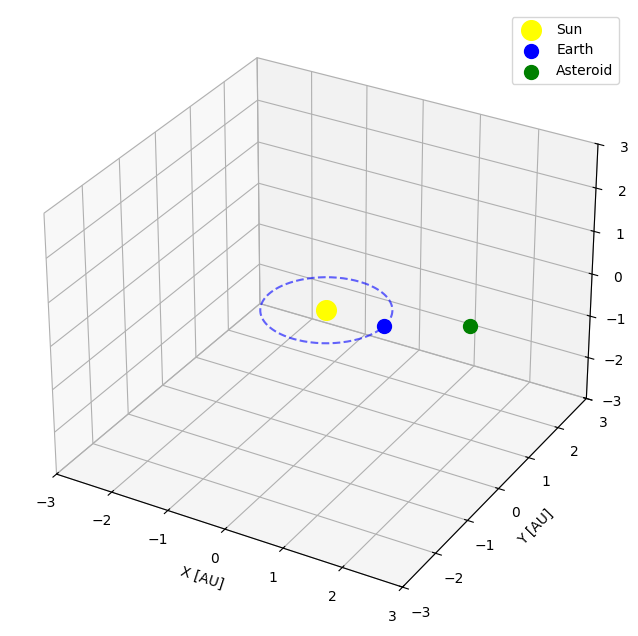

In [8]:
from mpl_toolkits.mplot3d import Axes3D
obstime = Time("2025-09-16T00:00:00", scale="tdb")


def plot_solar_system(earth_pos, asteroid_pos):
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, projection="3d")

    # sun at origin
    ax.scatter(0, 0, 0, c="yellow", s=200, label="Sun")

    # earth orbit 
    theta = np.linspace(0, 2*np.pi, 200)
    x_orbit = np.cos(theta) * 1.0
    y_orbit = np.sin(theta) * 1.0
    z_orbit = np.zeros_like(theta)
    ax.plot(x_orbit, y_orbit, z_orbit, "b--", alpha=0.6)
    ax.scatter(earth_pos[0], earth_pos[1], earth_pos[2], c="blue", s=100, label="Earth")

    # asteroid position
    ax.scatter(asteroid_pos[0], asteroid_pos[1], asteroid_pos[2],
               c="green", s=100, label="Asteroid")

    # mars position
    #theta = np.linspace(0, 2*np.pi, 200)
    #x_orbit1 = np.cos(theta) * 1.38
    #y_orbit1 = np.sin(theta) * 1.38
    #z_orbit1 = np.zeros_like(theta) * 1.38
    #ax.plot(x_orbit1, y_orbit1, z_orbit1, "b--", alpha=0.6)
    #ax.scatter(mars_pos[0], mars_pos[1], mars_pos[2], c="red", s=100, label="Mars")


    
    # labels, legend
    ax.set_xlabel("X [AU]")
    ax.set_ylabel("Y [AU]")
    ax.set_zlabel("Z [AU]")
    ax.legend()

    # aspect
    max_range = np.array([x_orbit.max()-x_orbit.min(), 
                          y_orbit.max()-y_orbit.min(), 
                          z_orbit.max()-z_orbit.min()]).max() / 2.0

    mid_x = (x_orbit.max()+x_orbit.min()) * 0.5
    mid_y = (y_orbit.max()+y_orbit.min()) * 0.5
    mid_z = (z_orbit.max()+z_orbit.min()) * 0.5
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_zlim(-3, 3)

    plt.show()



# earth at (1,0,0) AU
earth_pos = np.array([1.0, 0.0, 0.0])

# asteroid position 
# using it from r_vec from compute_neomod_weight
AU = 1.496e8  # km
asteroid_pos_km = np.array([3.56391834e8, 1.91209724e7, 6.91860069e7])
asteroid_pos = asteroid_pos_km / AU

plot_solar_system(earth_pos, asteroid_pos)
